In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from lime.lime_text import LimeTextExplainer

from utils.data_utils import load_and_preprocess_data

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42

## Load Saved Model and Data

In [3]:
nb_classifier = joblib.load('../../models/nb_model.joblib')
vectorizer = joblib.load('../../models/nb_vectorizer.joblib')

print("Model and vectorizer loaded successfully!")
print(f"Model classes: {nb_classifier.classes_}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Model and vectorizer loaded successfully!
Model classes: [0 1]
Vocabulary size: 5000


In [4]:
# Load and preprocess the same data used for training
X, y, df = load_and_preprocess_data(
    '../../data/enron_spam_data.csv',
    text_columns=['Subject', 'Message'],
    target_column='Spam/Ham',
    positive_class='spam',
    combine_text=True
)

# Recreate the same train/test split used during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y
)

# Also split the indices to track original emails
train_indices, test_indices = train_test_split(
    np.arange(len(X)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nClass distribution in test set:")
print(pd.Series(y_test).value_counts())

Loading data from ../../data/enron_spam_data.csv...
Dataset shape: (33716, 5)

Column names: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']

First few rows:
   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham  1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham  1999-12-14  

Dropped 609 rows with NaN values
Shape after dropping NaN: (33107, 5)
Dataset shape: (33716, 

In [5]:
X_test_vec = vectorizer.transform(X_test)

# Get predictions and probabilities
y_test_pred = nb_classifier.predict(X_test_vec)
y_test_proba = nb_classifier.predict_proba(X_test_vec)

## Overall Performance Summary

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98      3299
        Spam       0.98      0.99      0.98      3323

    accuracy                           0.98      6622
   macro avg       0.98      0.98      0.98      6622
weighted avg       0.98      0.98      0.98      6622



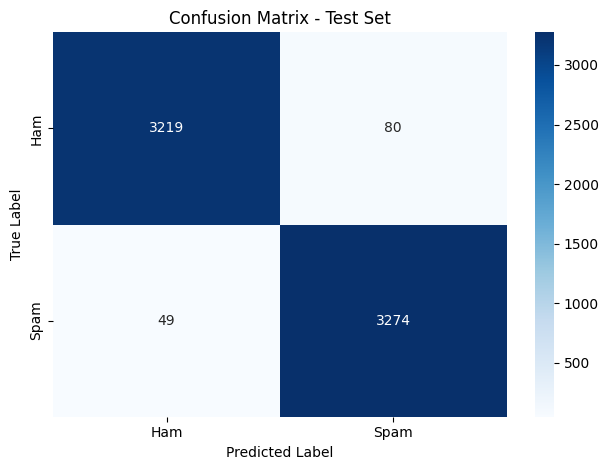


Error Breakdown:
True Negatives (Correctly predicted Ham): 3219
True Positives (Correctly predicted Spam): 3274
False Positives (Ham predicted as Spam): 80
False Negatives (Spam predicted as Ham): 49

Total Errors: 129 (1.95%)


In [6]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Ham', 'Spam']))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate error counts
tn, fp, fn, tp = cm.ravel()
print(f"\nError Breakdown:")
print(f"True Negatives (Correctly predicted Ham): {tn}")
print(f"True Positives (Correctly predicted Spam): {tp}")
print(f"False Positives (Ham predicted as Spam): {fp}")
print(f"False Negatives (Spam predicted as Ham): {fn}")
print(f"\nTotal Errors: {fp + fn} ({100 * (fp + fn) / len(y_test):.2f}%)")

## Identify and Categorize Errors

In [7]:
# Create a DataFrame with test results
test_results_df = pd.DataFrame({
    'text': X_test.values,
    'true_label': y_test.values,
    'predicted_label': y_test_pred,
    'ham_probability': y_test_proba[:, 0],
    'spam_probability': y_test_proba[:, 1],
    'confidence': np.max(y_test_proba, axis=1),
    'correct': y_test.values == y_test_pred
})

# Add text statistics
test_results_df['text_length'] = test_results_df['text'].str.len()
test_results_df['word_count'] = test_results_df['text'].str.split().str.len()
test_results_df['uppercase_ratio'] = test_results_df['text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0
)
test_results_df['exclamation_count'] = test_results_df['text'].str.count('!')
test_results_df['question_count'] = test_results_df['text'].str.count(r'\?')
test_results_df['dollar_count'] = test_results_df['text'].str.count(r'\$')
test_results_df['url_count'] = test_results_df['text'].str.count(r'http[s]?://')

# Categorize errors
false_positives = test_results_df[(test_results_df['true_label'] == 0) & 
                                   (test_results_df['predicted_label'] == 1)]
false_negatives = test_results_df[(test_results_df['true_label'] == 1) & 
                                   (test_results_df['predicted_label'] == 0)]
true_positives = test_results_df[(test_results_df['true_label'] == 1) & 
                                  (test_results_df['predicted_label'] == 1)]
true_negatives = test_results_df[(test_results_df['true_label'] == 0) & 
                                  (test_results_df['predicted_label'] == 0)]

print(f"False Positives (Ham → Spam): {len(false_positives)}")
print(f"False Negatives (Spam → Ham): {len(false_negatives)}")
print(f"True Positives (Spam → Spam): {len(true_positives)}")
print(f"True Negatives (Ham → Ham): {len(true_negatives)}")

False Positives (Ham → Spam): 80
False Negatives (Spam → Ham): 49
True Positives (Spam → Spam): 3274
True Negatives (Ham → Ham): 3219


## Error Pattern Analysis

### Text Length Analysis

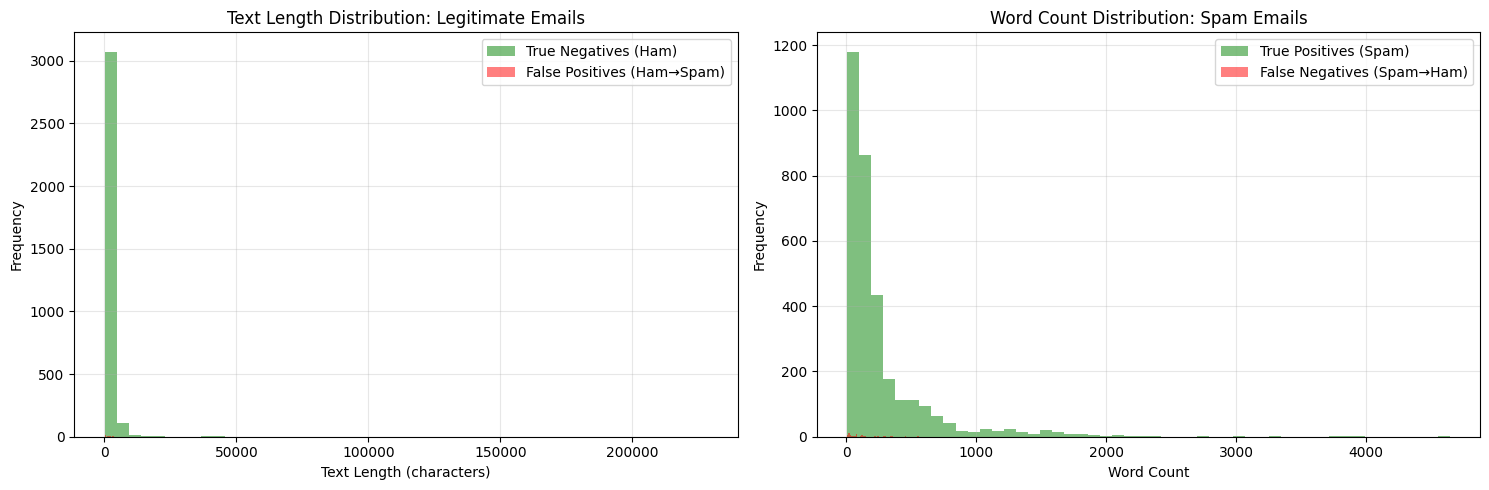

Text Length Statistics:

False Positives (Ham→Spam):
  Mean length: 1550.6 chars
  Mean words: 328.5

True Negatives (Correct Ham):
  Mean length: 1651.7 chars
  Mean words: 352.0

False Negatives (Spam→Ham):
  Mean length: 709.0 chars
  Mean words: 108.1

True Positives (Correct Spam):
  Mean length: 1341.7 chars
  Mean words: 267.1


In [8]:
# Compare text length distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character length
axes[0].hist(true_negatives['text_length'], bins=50, alpha=0.5, label='True Negatives (Ham)', color='green')
axes[0].hist(false_positives['text_length'], bins=50, alpha=0.5, label='False Positives (Ham→Spam)', color='red')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution: Legitimate Emails')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Word count
axes[1].hist(true_positives['word_count'], bins=50, alpha=0.5, label='True Positives (Spam)', color='green')
axes[1].hist(false_negatives['word_count'], bins=50, alpha=0.5, label='False Negatives (Spam→Ham)', color='red')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution: Spam Emails')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print("Text Length Statistics:")
print(f"\nFalse Positives (Ham→Spam):")
print(f"  Mean length: {false_positives['text_length'].mean():.1f} chars")
print(f"  Mean words: {false_positives['word_count'].mean():.1f}")
print(f"\nTrue Negatives (Correct Ham):")
print(f"  Mean length: {true_negatives['text_length'].mean():.1f} chars")
print(f"  Mean words: {true_negatives['word_count'].mean():.1f}")
print(f"\nFalse Negatives (Spam→Ham):")
print(f"  Mean length: {false_negatives['text_length'].mean():.1f} chars")
print(f"  Mean words: {false_negatives['word_count'].mean():.1f}")
print(f"\nTrue Positives (Correct Spam):")
print(f"  Mean length: {true_positives['text_length'].mean():.1f} chars")
print(f"  Mean words: {true_positives['word_count'].mean():.1f}")

### Special Character Analysis

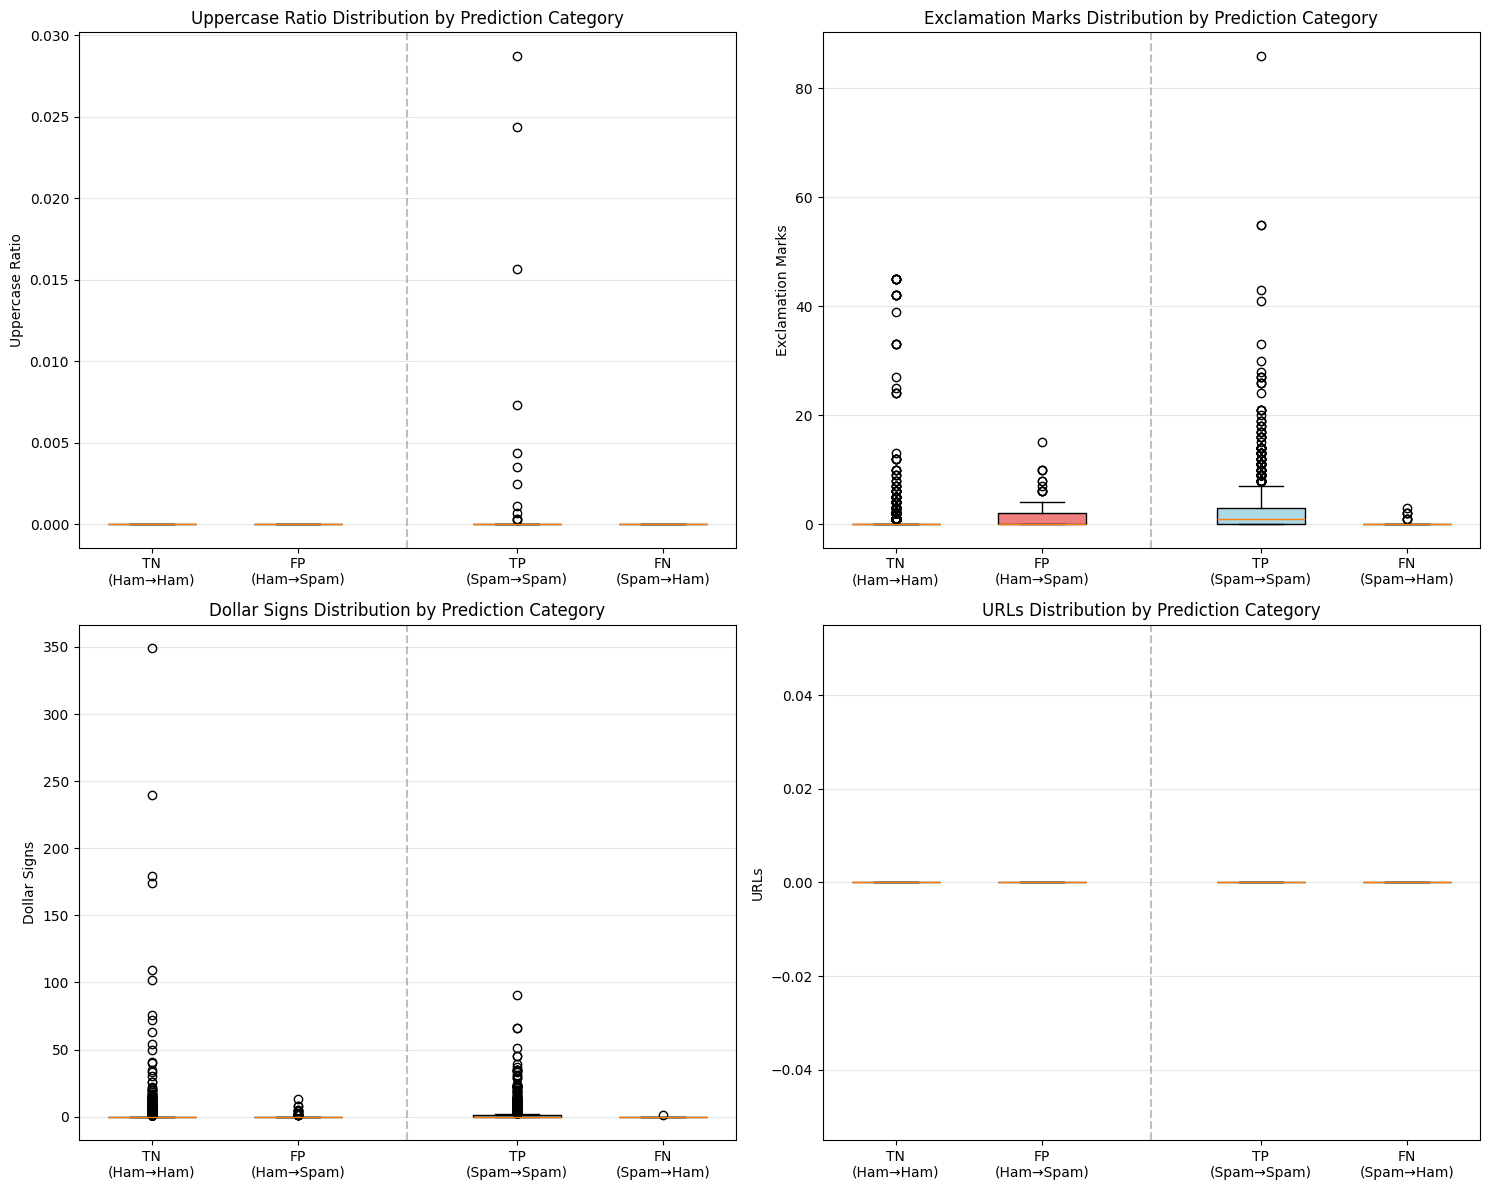

Special Character Statistics:

Uppercase Ratio:
  False Positives: mean=0.0000, std=0.0000
  True Negatives:  mean=0.0000, std=0.0000
  False Negatives: mean=0.0000, std=0.0000
  True Positives:  mean=0.0000, std=0.0007

Exclamation Marks:
  False Positives: mean=1.7750, std=3.0062
  True Negatives:  mean=0.5840, std=3.3011
  False Negatives: mean=0.2653, std=0.6701
  True Positives:  mean=1.8910, std=3.7865

Dollar Signs:
  False Positives: mean=0.8250, std=2.1570
  True Negatives:  mean=1.0572, std=9.6954
  False Negatives: mean=0.0204, std=0.1429
  True Positives:  mean=1.3943, std=4.4798

URLs:
  False Positives: mean=0.0000, std=0.0000
  True Negatives:  mean=0.0000, std=0.0000
  False Negatives: mean=0.0000, std=0.0000
  True Positives:  mean=0.0000, std=0.0000



In [9]:
# Compare special character usage
features_to_compare = ['uppercase_ratio', 'exclamation_count', 'dollar_count', 'url_count']
feature_labels = ['Uppercase Ratio', 'Exclamation Marks', 'Dollar Signs', 'URLs']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (feature, label) in enumerate(zip(features_to_compare, feature_labels)):
    # For False Positives vs True Negatives
    data_to_plot = [
        true_negatives[feature],
        false_positives[feature],
        true_positives[feature],
        false_negatives[feature]
    ]
    
    positions = [1, 2, 3.5, 4.5]
    labels_plot = ['TN\n(Ham→Ham)', 'FP\n(Ham→Spam)', 'TP\n(Spam→Spam)', 'FN\n(Spam→Ham)']
    colors = ['lightgreen', 'lightcoral', 'lightblue', 'orange']
    
    bp = axes[idx].boxplot(data_to_plot, positions=positions, tick_labels=labels_plot,
                           patch_artist=True, widths=0.6)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[idx].set_ylabel(label)
    axes[idx].set_title(f'{label} Distribution by Prediction Category')
    axes[idx].grid(alpha=0.3, axis='y')
    axes[idx].axvline(x=2.75, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print statistics
print("Special Character Statistics:\n")
for feature, label in zip(features_to_compare, feature_labels):
    print(f"{label}:")
    print(f"  False Positives: mean={false_positives[feature].mean():.4f}, std={false_positives[feature].std():.4f}")
    print(f"  True Negatives:  mean={true_negatives[feature].mean():.4f}, std={true_negatives[feature].std():.4f}")
    print(f"  False Negatives: mean={false_negatives[feature].mean():.4f}, std={false_negatives[feature].std():.4f}")
    print(f"  True Positives:  mean={true_positives[feature].mean():.4f}, std={true_positives[feature].std():.4f}")
    print()

### Confidence Analysis

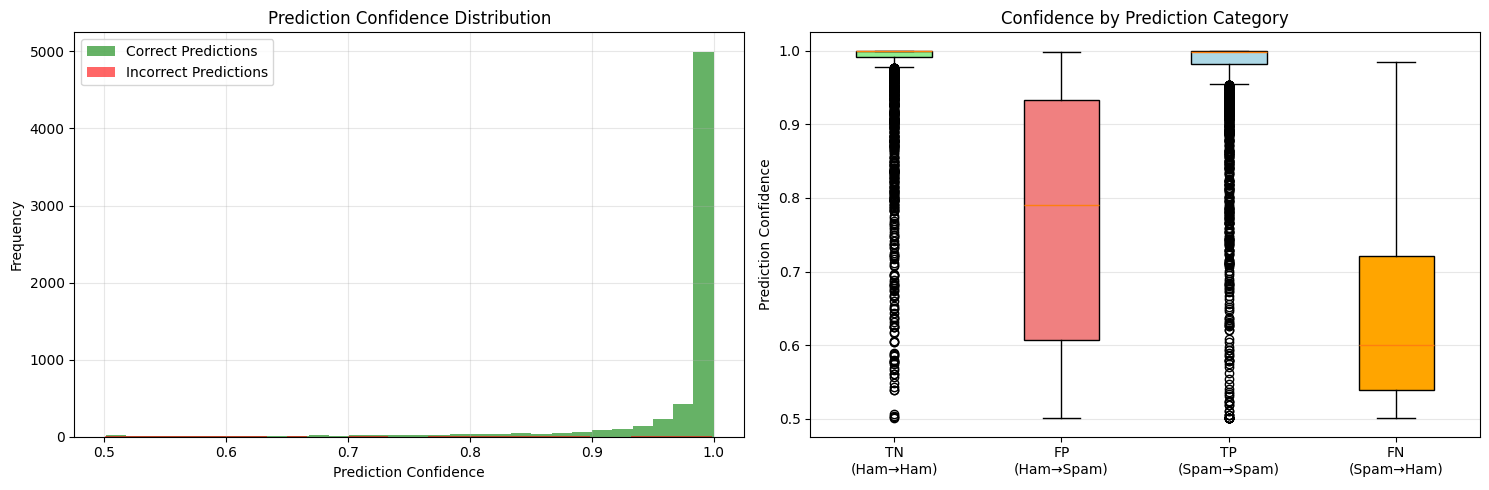

Correct Predictions: mean=0.9729
Incorrect Predictions: mean=0.7255
False Positives: mean=0.7734
False Negatives: mean=0.6472


In [10]:
# Analyze prediction confidence for errors vs correct predictions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of confidence scores
axes[0].hist(test_results_df[test_results_df['correct']]['confidence'], 
             bins=30, alpha=0.6, label='Correct Predictions', color='green')
axes[0].hist(test_results_df[~test_results_df['correct']]['confidence'], 
             bins=30, alpha=0.6, label='Incorrect Predictions', color='red')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Prediction Confidence Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
data_to_plot = [
    true_negatives['confidence'],
    false_positives['confidence'],
    true_positives['confidence'],
    false_negatives['confidence']
]
labels_plot = ['TN\n(Ham→Ham)', 'FP\n(Ham→Spam)', 'TP\n(Spam→Spam)', 'FN\n(Spam→Ham)']
colors = ['lightgreen', 'lightcoral', 'lightblue', 'orange']

bp = axes[1].boxplot(data_to_plot, tick_labels=labels_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[1].set_ylabel('Prediction Confidence')
axes[1].set_title('Confidence by Prediction Category')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Correct Predictions: mean={test_results_df[test_results_df['correct']]['confidence'].mean():.4f}")
print(f"Incorrect Predictions: mean={test_results_df[~test_results_df['correct']]['confidence'].mean():.4f}")
print(f"False Positives: mean={false_positives['confidence'].mean():.4f}")
print(f"False Negatives: mean={false_negatives['confidence'].mean():.4f}")

## Feature Importance and Model Interpretability

### Global Feature Importance

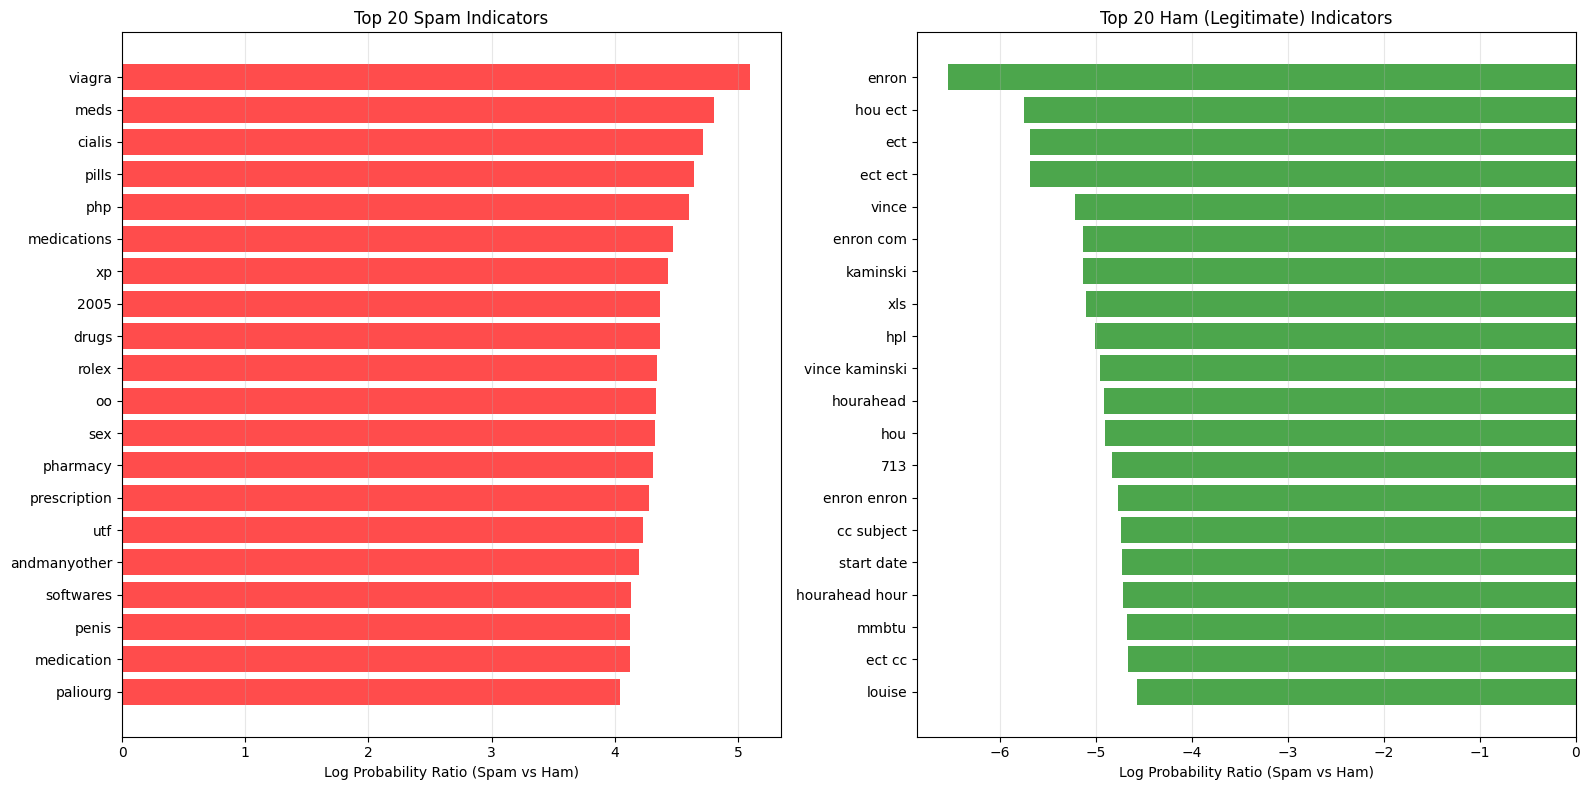

In [11]:
def get_feature_importance(vectorizer, classifier, n=20):
    """Extract feature importance from Naive Bayes model."""
    feature_names = vectorizer.get_feature_names_out()
    log_probs = classifier.feature_log_prob_
    
    # Calculate log probability ratio (spam vs ham)
    log_prob_ratio = log_probs[1] - log_probs[0]  # spam - ham
    
    # Top spam indicators (positive ratios)
    spam_indices = log_prob_ratio.argsort()[-n:][::-1]
    top_spam_features = [(feature_names[i], log_prob_ratio[i]) for i in spam_indices]
    
    # Top ham indicators (negative ratios)
    ham_indices = log_prob_ratio.argsort()[:n]
    top_ham_features = [(feature_names[i], log_prob_ratio[i]) for i in ham_indices]
    
    return top_spam_features, top_ham_features

top_spam_features, top_ham_features = get_feature_importance(vectorizer, nb_classifier, n=20)

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Spam features
spam_words = [f[0] for f in top_spam_features]
spam_scores = [f[1] for f in top_spam_features]
axes[0].barh(range(len(spam_words)), spam_scores, color='red', alpha=0.7)
axes[0].set_yticks(range(len(spam_words)))
axes[0].set_yticklabels(spam_words)
axes[0].set_xlabel('Log Probability Ratio (Spam vs Ham)')
axes[0].set_title('Top 20 Spam Indicators')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# Ham features
ham_words = [f[0] for f in top_ham_features]
ham_scores = [f[1] for f in top_ham_features]
axes[1].barh(range(len(ham_words)), ham_scores, color='green', alpha=0.7)
axes[1].set_yticks(range(len(ham_words)))
axes[1].set_yticklabels(ham_words)
axes[1].set_xlabel('Log Probability Ratio (Spam vs Ham)')
axes[1].set_title('Top 20 Ham (Legitimate) Indicators')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Individual Prediction Explanations

In [12]:
def explain_prediction(text, vectorizer, classifier, n_features=10):
    """
    Explain a single prediction by showing the most influential features.
    
    Parameters:
    -----------
    text : str
        The email text to explain
    vectorizer : TfidfVectorizer
        Fitted vectorizer
    classifier : MultinomialNB
        Trained classifier
    n_features : int
        Number of top features to show
    
    Returns:
    --------
    dict : Explanation details
    """
    # Get prediction
    text_vec = vectorizer.transform([text])
    prediction = classifier.predict(text_vec)[0]
    probabilities = classifier.predict_proba(text_vec)[0]
    
    # Get feature names and their values in the email
    feature_names = vectorizer.get_feature_names_out()
    text_features = text_vec.toarray()[0]
    
    # Get non-zero features (words present in the email)
    present_features = [(feature_names[i], text_features[i], i) 
                       for i in range(len(text_features)) if text_features[i] > 0]
    
    # Get log probabilities for each class
    log_probs = classifier.feature_log_prob_
    
    # Calculate feature contributions
    contributions = []
    for word, tfidf, idx in present_features:
        # Log probability ratio: positive means spam, negative means ham
        log_ratio = log_probs[1][idx] - log_probs[0][idx]
        # Weight by TF-IDF score
        contribution = tfidf * log_ratio
        contributions.append({
            'word': word,
            'tfidf': tfidf,
            'log_prob_ratio': log_ratio,
            'contribution': contribution,
            'direction': 'SPAM' if log_ratio > 0 else 'HAM'
        })
    
    # Sort by absolute contribution
    contributions.sort(key=lambda x: abs(x['contribution']), reverse=True)
    top_contributions = contributions[:n_features]
    
    return {
        'prediction': 'SPAM' if prediction == 1 else 'HAM',
        'spam_probability': probabilities[1],
        'ham_probability': probabilities[0],
        'confidence': max(probabilities),
        'top_features': top_contributions,
        'text': text
    }

def display_explanation(explanation):
    """Display a formatted explanation of a prediction."""
    print("EMAIL TEXT:")
    print(explanation['text'][:500] + ("..." if len(explanation['text']) > 500 else ""))
    print(f"PREDICTION: {explanation['prediction']}")
    print(f"Confidence: {explanation['confidence']:.2%}")
    print(f"Spam Probability: {explanation['spam_probability']:.2%}")
    print(f"Ham Probability: {explanation['ham_probability']:.2%}")
    print(f"TOP {len(explanation['top_features'])} INFLUENTIAL FEATURES:")
    
    for i, feat in enumerate(explanation['top_features'], 1):
        direction_symbol = "📧" if feat['direction'] == 'SPAM' else "✅"
        print(f"{i:2d}. {direction_symbol} '{feat['word']:<20s}' → {feat['direction']:<4s} "
              f"(contribution: {feat['contribution']:+.4f}, TF-IDF: {feat['tfidf']:.4f})")

### Analyze Misclassified Examples with Explanations

In [13]:
# Show examples of false positives with explanations
n_examples = min(3, len(false_positives))
for i, (idx, row) in enumerate(false_positives.head(n_examples).iterrows()):
    print(f"FALSE POSITIVE EXAMPLE {i+1}/{n_examples}:")
    explanation = explain_prediction(row['text'], vectorizer, nb_classifier)
    display_explanation(explanation)
    print("\n")

FALSE POSITIVE EXAMPLE 1/3:
EMAIL TEXT:
welcome to expedia . com ! welcome to expedia . com , your personal travel service on the web !
your member id is : jdfarmerl
expedia . com gives you a powerful set of tools to plan and shop for
airline tickets , hotel reservations , car reservations , and vacation
packages . the service is free ! just visit http : / / www . expedia . com , and begin
your travels .
now is a good time to make note of your password . you may also want to
save a copy of this message as a record of your member id . ...
PREDICTION: SPAM
Confidence: 93.46%
Spam Probability: 93.46%
Ham Probability: 6.54%
TOP 10 INFLUENTIAL FEATURES:
 1. 📧 'shop                ' → SPAM (contribution: +0.4685, TF-IDF: 0.1718)
 2. 📧 'http www            ' → SPAM (contribution: +0.3854, TF-IDF: 0.2336)
 3. 📧 'http                ' → SPAM (contribution: +0.3725, TF-IDF: 0.1813)
 4. 📧 'www                 ' → SPAM (contribution: +0.3123, TF-IDF: 0.2141)
 5. 📧 'com                 ' → SPAM (co

In [14]:
# Show examples of false negatives with explanations
n_examples = min(3, len(false_negatives))
for i, (idx, row) in enumerate(false_negatives.head(n_examples).iterrows()):
    print(f"FALSE NEGATIVE EXAMPLE {i+1}/{n_examples}:")
    explanation = explain_prediction(row['text'], vectorizer, nb_classifier)
    display_explanation(explanation)
    print("\n")

FALSE NEGATIVE EXAMPLE 1/3:
EMAIL TEXT:
peter g [ tour dates ] tour dates
friday 8 th - regua open air
saturday 9 th - super club
friday 15 th - hot rio club
saturday 16 th - forever
friday 22 nd - swing
saturday 23 rd - sub solo
friday 29 th - buddha club
saturday 30 th - * * free for booking * *
contact for booking
peterg . management @ gmail . com

PREDICTION: HAM
Confidence: 94.54%
Spam Probability: 5.46%
Ham Probability: 94.54%
TOP 10 INFLUENTIAL FEATURES:
 1. ✅ 'saturday            ' → HAM  (contribution: -1.0067, TF-IDF: 0.4548)
 2. ✅ 'friday              ' → HAM  (contribution: -0.7513, TF-IDF: 0.3154)
 3. ✅ 'dates               ' → HAM  (contribution: -0.4417, TF-IDF: 0.2239)
 4. ✅ 'th                  ' → HAM  (contribution: -0.3422, TF-IDF: 0.4288)
 5. 📧 'forever             ' → SPAM (contribution: +0.2943, TF-IDF: 0.1320)
 6. ✅ 'swing               ' → HAM  (contribution: -0.2756, TF-IDF: 0.1327)
 7. ✅ '16 th               ' → HAM  (contribution: -0.1810, TF-IDF: 0.1328)
 8

### Correctly Classified Examples

In [15]:
# Show examples of correct spam predictions
n_examples = min(2, len(true_positives))
for i, (idx, row) in enumerate(true_positives.head(n_examples).iterrows()):
    print(f"TRUE POSITIVE EXAMPLE {i+1}/{n_examples}:")
    explanation = explain_prediction(row['text'], vectorizer, nb_classifier)
    display_explanation(explanation)
    print("\n")

TRUE POSITIVE EXAMPLE 1/2:
EMAIL TEXT:
spice up your cellphone with a wallpaper from dirtyhippo . dress up your phone . visit here .
qdtnmivvmxhe
PREDICTION: SPAM
Confidence: 73.87%
Spam Probability: 73.87%
Ham Probability: 26.13%
TOP 2 INFLUENTIAL FEATURES:
 1. 📧 'visit               ' → SPAM (contribution: +0.7287, TF-IDF: 0.7182)
 2. 📧 'phone               ' → SPAM (contribution: +0.3033, TF-IDF: 0.6959)


TRUE POSITIVE EXAMPLE 2/2:
EMAIL TEXT:
re : pretty girl wants to meet a real woman remove
minnesota , which can clinch a wild - card
playoff spot with a loss by either carolina or st . louis this weekend , appeared on
its way to retaking the lead . but a holding penalty on birk - - the vikings were
flagged nine times for 78 yards - - wiped out a 16 - yard run by michael bennett that
would have given them the ball at the green bay 40 just before the 2 - minute warning .
the vikings ( 8 - 7 ) , though , couldn ' t
get what they needed ...
PREDICTION: SPAM
Confidence: 83.46%
Spam Pro

## LIME Explanations

In [16]:
explainer = LimeTextExplainer(class_names=['Ham', 'Spam'])

def predict_proba_for_lime(texts):
    """Wrapper function for LIME."""
    text_vec = vectorizer.transform(texts)
    return nb_classifier.predict_proba(text_vec)

### LIME Explanations for False Positives

Email text (first 300 chars):
welcome to expedia . com ! welcome to expedia . com , your personal travel service on the web !
your member id is : jdfarmerl
expedia . com gives you a powerful set of tools to plan and shop for
airline tickets , hotel reservations , car reservations , and vacation
packages . the service is free ! j...

LIME Explanation (Top features):
[(np.str_('http'), 0.11542481609815358), (np.str_('www'), 0.08690788208886294), (np.str_('shop'), 0.07851138487205657), (np.str_('privacy'), 0.0387160109868954), (np.str_('password'), -0.026549238367519833), (np.str_('tickets'), -0.020489891169448462), (np.str_('reserve'), -0.019239091331272835), (np.str_('daily'), -0.016902193454878974), (np.str_('vacation'), -0.011981648449317137), (np.str_('trip'), -0.01025005798578203)]

LIME Explanation (Top features):
[(np.str_('http'), 0.11542481609815358), (np.str_('www'), 0.08690788208886294), (np.str_('shop'), 0.07851138487205657), (np.str_('privacy'), 0.0387160109868954), (np.str_

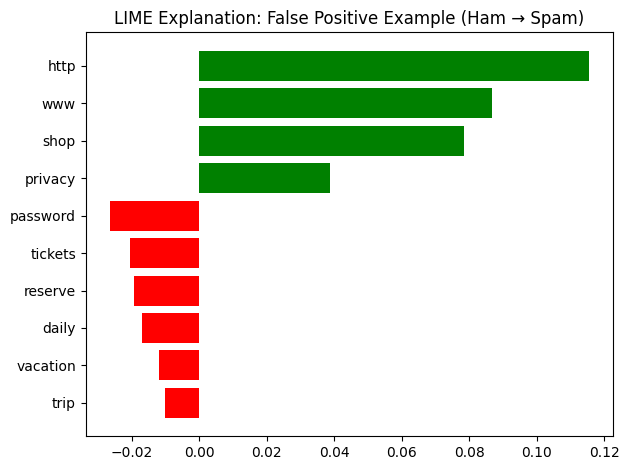

In [17]:
if len(false_positives) > 0:
    fp_example = false_positives.iloc[0]['text']
    
    print("Email text (first 300 chars):")
    print(fp_example[:300] + "...")
    
    exp = explainer.explain_instance(
        fp_example, 
        predict_proba_for_lime, 
        num_features=10,
        num_samples=1000
    )
    
    print("\nLIME Explanation (Top features):")
    print(exp.as_list())
    
    fig = exp.as_pyplot_figure()
    plt.title('LIME Explanation: False Positive Example (Ham → Spam)')
    plt.tight_layout()
    plt.show()

### LIME Explanations for False Negatives

Email text (first 300 chars):
peter g [ tour dates ] tour dates
friday 8 th - regua open air
saturday 9 th - super club
friday 15 th - hot rio club
saturday 16 th - forever
friday 22 nd - swing
saturday 23 rd - sub solo
friday 29 th - buddha club
saturday 30 th - * * free for booking * *
contact for booking
peterg . management @...

LIME Explanation (Top features):
[(np.str_('saturday'), -0.13208065367663446), (np.str_('friday'), -0.10890194368560988), (np.str_('dates'), -0.07415769474841591), (np.str_('th'), -0.062201784511015455), (np.str_('swing'), -0.046526997242260476), (np.str_('forever'), 0.042417321764753026), (np.str_('club'), 0.03711560594027147), (np.str_('air'), 0.02709073914116841), (np.str_('hot'), 0.02474738252547191), (np.str_('super'), 0.024735111174706486)]

LIME Explanation (Top features):
[(np.str_('saturday'), -0.13208065367663446), (np.str_('friday'), -0.10890194368560988), (np.str_('dates'), -0.07415769474841591), (np.str_('th'), -0.062201784511015455), (np.str_(

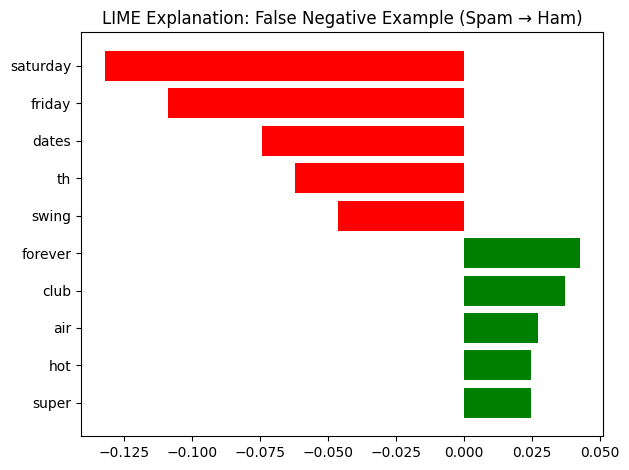

In [18]:
if len(false_negatives) > 0:
    fn_example = false_negatives.iloc[0]['text']
    
    print("Email text (first 300 chars):")
    print(fn_example[:300] + "...")
    
    exp = explainer.explain_instance(
        fn_example, 
        predict_proba_for_lime, 
        num_features=10,
        num_samples=1000
    )
    
    print("\nLIME Explanation (Top features):")
    print(exp.as_list())
    
    fig = exp.as_pyplot_figure()
    plt.title('LIME Explanation: False Negative Example (Spam → Ham)')
    plt.tight_layout()
    plt.show()

### LIME Explanations for Correct Predictions

Email text (first 300 chars):
spice up your cellphone with a wallpaper from dirtyhippo . dress up your phone . visit here .
qdtnmivvmxhe...

LIME Explanation (Top features):
[(np.str_('visit'), 0.1608725443256856), (np.str_('phone'), 0.040107746878171965), (np.str_('spice'), 0.004944267038989379), (np.str_('a'), 0.002820889174597757), (np.str_('dirtyhippo'), 0.0023940881971341436), (np.str_('here'), 0.001910877787743489), (np.str_('up'), 0.0018888362226527464), (np.str_('your'), -0.0013947144994178554), (np.str_('cellphone'), -0.0012967241854766264), (np.str_('with'), -0.000894250493076113)]


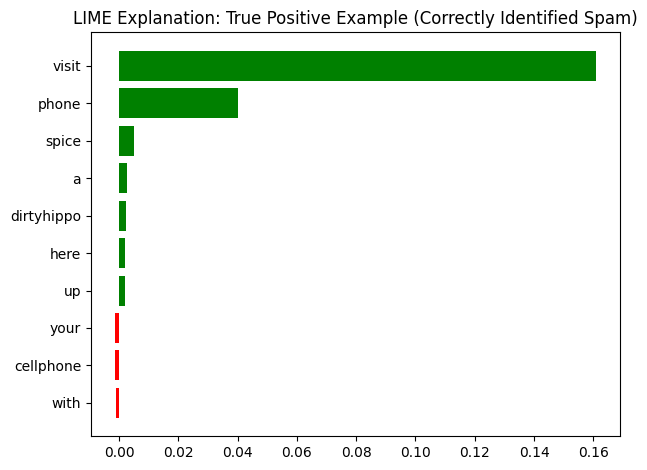

In [19]:
if len(true_positives) > 0:
    tp_example = true_positives.iloc[0]['text']
    
    print("Email text (first 300 chars):")
    print(tp_example[:300] + "...")
    
    exp = explainer.explain_instance(
        tp_example, 
        predict_proba_for_lime, 
        num_features=10,
        num_samples=1000
    )
    
    print("\nLIME Explanation (Top features):")
    print(exp.as_list())
    
    fig = exp.as_pyplot_figure()
    plt.title('LIME Explanation: True Positive Example (Correctly Identified Spam)')
    plt.tight_layout()
    plt.show()

## Summary of Error Patterns

In [20]:
print("1. OVERALL ERROR RATE:")
print(f"   Total errors: {len(false_positives) + len(false_negatives)} / {len(y_test)}")
print(f"   Error rate: {100 * (len(false_positives) + len(false_negatives)) / len(y_test):.2f}%")

print("\n2. ERROR BREAKDOWN:")
print(f"   False Positives (Ham → Spam): {len(false_positives)} ({100*len(false_positives)/len(y_test):.2f}%)")
print(f"   False Negatives (Spam → Ham): {len(false_negatives)} ({100*len(false_negatives)/len(y_test):.2f}%)")

print("\n3. TEXT LENGTH PATTERNS:")
if len(false_positives) > 0:
    fp_avg_len = false_positives['text_length'].mean()
    tn_avg_len = true_negatives['text_length'].mean()
    print(f"   False Positives average length: {fp_avg_len:.1f} chars")
    print(f"   True Negatives average length: {tn_avg_len:.1f} chars")
    print(f"   Difference: {fp_avg_len - tn_avg_len:+.1f} chars ({100*(fp_avg_len-tn_avg_len)/tn_avg_len:+.1f}%)")

if len(false_negatives) > 0:
    fn_avg_len = false_negatives['text_length'].mean()
    tp_avg_len = true_positives['text_length'].mean()
    print(f"\n   False Negatives average length: {fn_avg_len:.1f} chars")
    print(f"   True Positives average length: {tp_avg_len:.1f} chars")
    print(f"   Difference: {fn_avg_len - tp_avg_len:+.1f} chars ({100*(fn_avg_len-tp_avg_len)/tp_avg_len:+.1f}%)")

print("\n4. CONFIDENCE PATTERNS:")
if len(false_positives) > 0:
    print(f"   False Positive average confidence: {false_positives['confidence'].mean():.4f}")
if len(false_negatives) > 0:
    print(f"   False Negative average confidence: {false_negatives['confidence'].mean():.4f}")
print(f"   Correct predictions average confidence: {test_results_df[test_results_df['correct']]['confidence'].mean():.4f}")

1. OVERALL ERROR RATE:
   Total errors: 129 / 6622
   Error rate: 1.95%

2. ERROR BREAKDOWN:
   False Positives (Ham → Spam): 80 (1.21%)
   False Negatives (Spam → Ham): 49 (0.74%)

3. TEXT LENGTH PATTERNS:
   False Positives average length: 1550.6 chars
   True Negatives average length: 1651.7 chars
   Difference: -101.1 chars (-6.1%)

   False Negatives average length: 709.0 chars
   True Positives average length: 1341.7 chars
   Difference: -632.7 chars (-47.2%)

4. CONFIDENCE PATTERNS:
   False Positive average confidence: 0.7734
   False Negative average confidence: 0.6472
   Correct predictions average confidence: 0.9729
